In [1]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List, Mapping, MutableMapping, Optional, Protocol, Tuple, Type, TypeVar, Generic
from collections import defaultdict, deque
import math

# -------------------------
# Core Data Model
# -------------------------

@dataclass
class Attribute:
    name: str
    dtype: Type = object
    value: Any = None
    unit: str = ""
    description: str = ""
    label: str = ""
    required: bool = False


@dataclass
class ProcessData:
    """Container für Daten + Metadaten.

    - attrs: Map von Attributname -> Attribute
    - Methoden add/get/is_complete
    """
    name: str = "data"
    attrs: Dict[str, Attribute] = field(default_factory=dict)

    def add(self, name: str, value: Any = None, dtype: Type = object, **kw) -> None:
        self.attrs[name] = Attribute(name=name, value=value, dtype=dtype, **kw)

    def get(self, name: str) -> Attribute:
        if name not in self.attrs:
            raise KeyError(f"Attribut '{name}' fehlt in {self.name}.")
        return self.attrs[name]

    def is_complete(self) -> bool:
        for a in self.attrs.values():
            if a.required and a.value is None:
                return False
        return True

    # Convenience: Direktzugriff via .value, .dtype
    @property
    def md(self) -> Mapping[str, Attribute]:
        return self.attrs


# -------------------------
# Ports & Nodes
# -------------------------

@dataclass(frozen=True)
class PortSpec:
    name: str
    dtype: Type[ProcessData] = ProcessData
    optional: bool = False
    many: bool = False  # Mehrfach zulässig (Liste von Verbindungen)


I = TypeVar("I", bound=ProcessData)
O = TypeVar("O", bound=ProcessData)


class Node(Protocol):
    name: str
    input_ports: Mapping[str, PortSpec]
    output_ports: Mapping[str, PortSpec]

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        ...

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        ...


@dataclass
class BaseNode:
    name: str = "Node"
    input_ports: Dict[str, PortSpec] = field(default_factory=dict)
    output_ports: Dict[str, PortSpec] = field(default_factory=dict)

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        # 1) Alle geforderten Ports vorhanden?
        for pname, pspec in self.input_ports.items():
            if not pspec.optional and pname not in inputs:
                raise ValueError(f"[{self.name}] Fehlender Input-Port: {pname}")

        # 2) Typ & Vollständigkeit prüfen
        for pname, pdata in inputs.items():
            if pname not in self.input_ports:
                raise ValueError(f"[{self.name}] Unerwarteter Input-Port: {pname}")
            pspec = self.input_ports[pname]
            if not isinstance(pdata, pspec.dtype):
                raise TypeError(
                    f"[{self.name}] Port '{pname}' erwartet {pspec.dtype.__name__}, bekam {type(pdata).__name__}"
                )
            if not pdata.is_complete():
                raise ValueError(f"[{self.name}] Port '{pname}' ist nicht vollständig.")

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        raise NotImplementedError


# -------------------------
# Beispiel-spezifische Daten & Nodes
# -------------------------

class SpecificInput(ProcessData):
    def __init__(self, name: str = "SpecificInput", **kwargs: Any):
        super().__init__(name=name)
        # Default-Attribute
        self.add("a", None, float, unit="-", description="my a value", label="$a$", required=True)
        self.add("b", None, int, unit="MPa", description="my b value", label="$b$", required=True)
        # Werte aus kwargs setzen (vereinfachte Variante):
        for k, v in kwargs.items():
            if k in self.attrs:
                self.attrs[k].value = v
            else:
                # On-the-fly Zusatzattribut
                self.add(k, v)


class SpecificOutput(ProcessData):
    pass


@dataclass
class SpecificProcessNode(BaseNode):
    """c = a + b"""
    def __init__(self, name: str = "SpecificProcess"):
        super().__init__(
            name=name,
            input_ports={
                "input": PortSpec("input", dtype=SpecificInput)
            },
            output_ports={
                "output": PortSpec("output", dtype=SpecificOutput)
            }
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificInput = inputs["input"]  # type: ignore[assignment]
        a = inp.get("a").value
        b = inp.get("b").value
        out = SpecificOutput(name="out")
        out.add("c", a + b, float, description="a+b")
        return {"output": out}


@dataclass
class SquareNode(BaseNode):
    """d = c**2"""
    def __init__(self, name: str = "Square"):
        super().__init__(
            name=name,
            input_ports={"input": PortSpec("input", dtype=SpecificOutput)},
            output_ports={"output": PortSpec("output", dtype=SpecificOutput)},
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificOutput = inputs["input"]  # type: ignore[assignment]
        c = inp.get("c").value
        out = SpecificOutput(name="out2")
        out.add("d", float(c) ** 2, float, description="(a+b)^2")
        return {"output": out}


# -------------------------
# Prozessgraph (DAG) & Runner
# -------------------------

@dataclass(frozen=True)
class Edge:
    src_node: str
    src_port: str
    dst_node: str
    dst_port: str


@dataclass
class ProcessGraph:
    nodes: Dict[str, BaseNode] = field(default_factory=dict)
    edges: List[Edge] = field(default_factory=list)

    def add_node(self, node_id: str, node: BaseNode) -> None:
        if node_id in self.nodes:
            raise KeyError(f"Node-ID bereits vergeben: {node_id}")
        self.nodes[node_id] = node

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        s_node, s_port = src
        d_node, d_port = dst
        if s_node not in self.nodes or d_node not in self.nodes:
            raise KeyError("Quelle oder Ziel-Node unbekannt")
        self.edges.append(Edge(s_node, s_port, d_node, d_port))

    def _toposort(self, external_inputs: Dict[Tuple[str, str], ProcessData]) -> List[str]:
        # Kantenstruktur: von Node -> Liste Zielknoten
        outgoing: Dict[str, List[str]] = defaultdict(list)
        indeg: Dict[str, int] = {nid: 0 for nid in self.nodes}

        # Indegree zählt nur Kanten, die *Pflicht*-Inputs abdecken; optional ignorieren
        for e in self.edges:
            outgoing[e.src_node].append(e.dst_node)
            dst_node = self.nodes[e.dst_node]
            pspec = dst_node.input_ports.get(e.dst_port)
            if pspec and not pspec.optional:
                indeg[e.dst_node] += 1

        # Externe Inputs reduzieren die Indegree-Anforderungen
        for (nid, port), _ in external_inputs.items():
            node = self.nodes[nid]
            pspec = node.input_ports.get(port)
            if pspec and not pspec.optional:
                # Wenn es keine eingehende Kante für diesen Pflichtport gibt, dann gilt er als gedeckt
                # (praktisch: wir behandeln externen Input wie eine Kante von einer "Quelle").
                # Indegree auf keinen Fall unter 0 bringen.
                indeg[nid] = max(0, indeg[nid] - 1)

        q = deque([nid for nid, d in indeg.items() if d == 0])
        order: List[str] = []
        seen = set()
        while q:
            u = q.popleft()
            if u in seen:
                continue
            seen.add(u)
            order.append(u)
            for v in outgoing[u]:
                # Only decrement if that edge feeds a required port
                pspec = self.nodes[v].input_ports.get(
                    next((e.dst_port for e in self.edges if e.src_node == u and e.dst_node == v), "")
                )
                if pspec and not pspec.optional:
                    indeg[v] -= 1
                    if indeg[v] == 0:
                        q.append(v)
        if len(order) != len(self.nodes):
            raise RuntimeError("Zyklische Abhängigkeiten oder unaufgelöste Pflicht-Inputs im Graphen.")
        return order

    def run(
        self,
        external_inputs: Dict[Tuple[str, str], ProcessData],
        wanted_outputs: Optional[List[Tuple[str, str]]] = None,
    ) -> Dict[Tuple[str, str], ProcessData]:
        """Führt den DAG aus.

        external_inputs: Mapping (node_id, port_name) -> ProcessData
        wanted_outputs: Liste der gewünschten Ergebnis-Ports
        """
        # Eingangs-Puffer je Node/Port
        inbox: Dict[str, Dict[str, ProcessData]] = defaultdict(dict)
        for (nid, port), pdata in external_inputs.items():
            inbox[nid][port] = pdata

        # Kantenindex src -> [(dst, dst_port, src_port)]
        fanout: Dict[str, List[Tuple[str, str, str]]] = defaultdict(list)
        for e in self.edges:
            fanout[e.src_node].append((e.dst_node, e.dst_port, e.src_port))

        order = self._toposort(external_inputs)

        # Ausführen, sobald Inputs eines Nodes valide sind
        produced: Dict[Tuple[str, str], ProcessData] = {}
        for nid in order:
            node = self.nodes[nid]
            # Prüfen, ob für alle Pflicht-Ports Daten da sind
            inputs = inbox.get(nid, {})

            # Falls Ports optional sind, stört das Fehlen nicht; validate_inputs prüft Pflichtports
            node.validate_inputs(inputs)
            outputs = node.run(inputs)

            # Outputs verteilen
            for oport, pdata in outputs.items():
                produced[(nid, oport)] = pdata
                for (dst, dport, sport) in fanout[nid]:
                    if sport == oport:
                        inbox[dst][dport] = pdata

        if wanted_outputs is None:
            # Standard: Alle Leaf-Outputs liefern
            # Leafs = Nodes ohne ausgehende Kanten
            has_out = {e.src_node for e in self.edges}
            leafs = [nid for nid in self.nodes if nid not in has_out]
            wanted_outputs = []
            for nid in leafs:
                for op in self.nodes[nid].output_ports.keys():
                    wanted_outputs.append((nid, op))

        result = {key: produced[key] for key in wanted_outputs if key in produced}
        return result


# -------------------------
# CompositeNode: Bündelt Teilprozesse zu einem Prozess
# -------------------------

@dataclass
class CompositeNode(BaseNode):
    graph: ProcessGraph = field(default_factory=ProcessGraph)
    # Externe Ports des Composite -> interne Node/Port
    in_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)
    out_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)

    def __init__(self, name: str = "Composite"):
        super().__init__(name=name)
        self.graph = ProcessGraph()
        self.in_map = {}
        self.out_map = {}
        self.input_ports = {}
        self.output_ports = {}

    def expose_input(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.in_map[external_name] = (node_id, port)
        self.input_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def expose_output(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.out_map[external_name] = (node_id, port)
        self.output_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def add(self, node_id: str, node: BaseNode) -> None:
        self.graph.add_node(node_id, node)

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        self.graph.connect(src, dst)

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        # 1) Composite-Inputs auf interne Ziele abbilden
        ext_in: Dict[Tuple[str, str], ProcessData] = {}
        for ename, pdata in inputs.items():
            if ename not in self.in_map:
                raise KeyError(f"[{self.name}] Unbekannter Composite-Input: {ename}")
            nid, port = self.in_map[ename]
            ext_in[(nid, port)] = pdata

        # 2) Ausführen
        wanted = [(nid, port) for (oname, (nid, port)) in self.out_map.items()]
        produced = self.graph.run(ext_in, wanted_outputs=wanted)

        # 3) Interne Outputs auf externe Namen mappen
        out: Dict[str, ProcessData] = {}
        for oname, (nid, port) in self.out_map.items():
            val = produced.get((nid, port))
            if val is None:
                raise RuntimeError(f"[{self.name}] Erwarteter Output fehlt: {oname}")
            out[oname] = val
        return out


# -------------------------
# Demo
# -------------------------
if __name__ == "__main__":
    # Einzelne Nodes
    n1 = SpecificProcessNode()
    n2 = SquareNode()

    # Graph
    g = ProcessGraph()
    g.add_node("sum", n1)
    g.add_node("sq", n2)
    g.connect(("sum", "output"), ("sq", "input"))

    # Composite
    comp = CompositeNode(name="Pipeline")
    comp.add("sum", n1)
    comp.add("sq", n2)
    comp.connect(("sum", "output"), ("sq", "input"))
    comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
    comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

    # Eingaben
    inp = SpecificInput(name="input", a=1.2, b=3)

    # Direkt über Graph
    out_graph = g.run({("sum", "input"): inp})
    print("Graph leaf outputs:")
    for (nid, port), pdata in out_graph.items():
        print(nid, port, {k: v.value for k, v in pdata.md.items()})

    # Über Composite
    out_comp = comp.run({"pipeline_input": inp})
    print("Composite output:")
    for k, pdata in out_comp.items():
        print(k, {k2: v.value for k2, v in pdata.md.items()})


Graph leaf outputs:
sq output {'d': 17.64}
Composite output:
pipeline_output {'d': 17.64}


In [5]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List, Mapping, MutableMapping, Optional, Protocol, Tuple, Type, TypeVar, Generic
from collections import defaultdict, deque
import math

# -------------------------
# Core Data Model
# -------------------------

@dataclass
class Attribute:
    name: str
    dtype: Type = object
    value: Any = None
    unit: str = ""
    description: str = ""
    label: str = ""
    required: bool = False


@dataclass
class ProcessData:
    """Container für Daten + Metadaten.

    - attrs: Map von Attributname -> Attribute
    - Methoden add/get/is_complete
    """
    name: str = "data"
    attrs: Dict[str, Attribute] = field(default_factory=dict)

    def add(self, name: str, value: Any = None, dtype: Type = object, **kw) -> None:
        self.attrs[name] = Attribute(name=name, value=value, dtype=dtype, **kw)

    def get(self, name: str) -> Attribute:
        if name not in self.attrs:
            raise KeyError(f"Attribut '{name}' fehlt in {self.name}.")
        return self.attrs[name]

    def is_complete(self) -> bool:
        for a in self.attrs.values():
            if a.required and a.value is None:
                return False
        return True

    # Convenience: Direktzugriff via .value, .dtype
    @property
    def md(self) -> Mapping[str, Attribute]:
        return self.attrs


# -------------------------
# Ports & Nodes
# -------------------------

@dataclass(frozen=True)
class PortSpec:
    name: str
    dtype: Type[ProcessData] = ProcessData
    optional: bool = False
    many: bool = False  # Mehrfach zulässig (Liste von Verbindungen)


I = TypeVar("I", bound=ProcessData)
O = TypeVar("O", bound=ProcessData)


class Node(Protocol):
    name: str
    input_ports: Mapping[str, PortSpec]
    output_ports: Mapping[str, PortSpec]

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        ...

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        ...


@dataclass
class BaseNode:
    name: str = "Node"
    input_ports: Dict[str, PortSpec] = field(default_factory=dict)
    output_ports: Dict[str, PortSpec] = field(default_factory=dict)

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        # 1) Alle geforderten Ports vorhanden?
        for pname, pspec in self.input_ports.items():
            if not pspec.optional and pname not in inputs:
                raise ValueError(f"[{self.name}] Fehlender Input-Port: {pname}")

        # 2) Typ & Vollständigkeit prüfen
        for pname, pdata in inputs.items():
            if pname not in self.input_ports:
                raise ValueError(f"[{self.name}] Unerwarteter Input-Port: {pname}")
            pspec = self.input_ports[pname]
            if not isinstance(pdata, pspec.dtype):
                raise TypeError(
                    f"[{self.name}] Port '{pname}' erwartet {pspec.dtype.__name__}, bekam {type(pdata).__name__}"
                )
            if not pdata.is_complete():
                raise ValueError(f"[{self.name}] Port '{pname}' ist nicht vollständig.")

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        raise NotImplementedError


# -------------------------
# Beispiel-spezifische Daten & Nodes
# -------------------------

class SpecificInput(ProcessData):
    def __init__(self, name: str = "SpecificInput", **kwargs: Any):
        super().__init__(name=name)
        # Default-Attribute
        self.add("a", None, float, unit="-", description="my a value", label="$a$", required=True)
        self.add("b", None, int, unit="MPa", description="my b value", label="$b$", required=True)
        # Werte aus kwargs setzen (vereinfachte Variante):
        for k, v in kwargs.items():
            if k in self.attrs:
                self.attrs[k].value = v
            else:
                # On-the-fly Zusatzattribut
                self.add(k, v)


class SpecificOutput(ProcessData):
    pass


@dataclass
class SpecificProcessNode(BaseNode):
    """c = a + b"""
    def __init__(self, name: str = "SpecificProcess"):
        super().__init__(
            name=name,
            input_ports={
                "input": PortSpec("input", dtype=SpecificInput)
            },
            output_ports={
                "output": PortSpec("output", dtype=SpecificOutput)
            }
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificInput = inputs["input"]  # type: ignore[assignment]
        a = inp.get("a").value
        b = inp.get("b").value
        out = SpecificOutput(name="out")
        out.add("c", a + b, float, description="a+b")
        return {"output": out}


@dataclass
class SquareNode(BaseNode):
    """d = c**2"""
    def __init__(self, name: str = "Square"):
        super().__init__(
            name=name,
            input_ports={"input": PortSpec("input", dtype=SpecificOutput)},
            output_ports={"output": PortSpec("output", dtype=SpecificOutput)},
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificOutput = inputs["input"]  # type: ignore[assignment]
        c = inp.get("c").value
        out = SpecificOutput(name="out2")
        out.add("d", float(c) ** 2, float, description="(a+b)^2")
        return {"output": out}


# -------------------------
# Prozessgraph (DAG) & Runner
# -------------------------

@dataclass(frozen=True)
class Edge:
    src_node: str
    src_port: str
    dst_node: str
    dst_port: str


@dataclass
class ProcessGraph:
    nodes: Dict[str, BaseNode] = field(default_factory=dict)
    edges: List[Edge] = field(default_factory=list)

    def add_node(self, node_id: str, node: BaseNode) -> None:
        if node_id in self.nodes:
            raise KeyError(f"Node-ID bereits vergeben: {node_id}")
        self.nodes[node_id] = node

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        s_node, s_port = src
        d_node, d_port = dst
        if s_node not in self.nodes or d_node not in self.nodes:
            raise KeyError("Quelle oder Ziel-Node unbekannt")
        self.edges.append(Edge(s_node, s_port, d_node, d_port))

    def _toposort(self, external_inputs: Dict[Tuple[str, str], ProcessData]) -> List[str]:
        # Kantenstruktur: von Node -> Liste Zielknoten
        outgoing: Dict[str, List[str]] = defaultdict(list)
        indeg: Dict[str, int] = {nid: 0 for nid in self.nodes}

        # Indegree zählt nur Kanten, die *Pflicht*-Inputs abdecken; optional ignorieren
        for e in self.edges:
            outgoing[e.src_node].append(e.dst_node)
            dst_node = self.nodes[e.dst_node]
            pspec = dst_node.input_ports.get(e.dst_port)
            if pspec and not pspec.optional:
                indeg[e.dst_node] += 1

        # Externe Inputs reduzieren die Indegree-Anforderungen
        for (nid, port), _ in external_inputs.items():
            node = self.nodes[nid]
            pspec = node.input_ports.get(port)
            if pspec and not pspec.optional:
                # Wenn es keine eingehende Kante für diesen Pflichtport gibt, dann gilt er als gedeckt
                # (praktisch: wir behandeln externen Input wie eine Kante von einer "Quelle").
                # Indegree auf keinen Fall unter 0 bringen.
                indeg[nid] = max(0, indeg[nid] - 1)

        q = deque([nid for nid, d in indeg.items() if d == 0])
        order: List[str] = []
        seen = set()
        while q:
            u = q.popleft()
            if u in seen:
                continue
            seen.add(u)
            order.append(u)
            for v in outgoing[u]:
                # Only decrement if that edge feeds a required port
                pspec = self.nodes[v].input_ports.get(
                    next((e.dst_port for e in self.edges if e.src_node == u and e.dst_node == v), "")
                )
                if pspec and not pspec.optional:
                    indeg[v] -= 1
                    if indeg[v] == 0:
                        q.append(v)
        if len(order) != len(self.nodes):
            raise RuntimeError("Zyklische Abhängigkeiten oder unaufgelöste Pflicht-Inputs im Graphen.")
        return order

    def run(
        self,
        external_inputs: Dict[Tuple[str, str], ProcessData],
        wanted_outputs: Optional[List[Tuple[str, str]]] = None,
    ) -> Dict[Tuple[str, str], ProcessData]:
        """Führt den DAG aus.

        external_inputs: Mapping (node_id, port_name) -> ProcessData
        wanted_outputs: Liste der gewünschten Ergebnis-Ports
        """
        # Eingangs-Puffer je Node/Port
        inbox: Dict[str, Dict[str, ProcessData]] = defaultdict(dict)
        for (nid, port), pdata in external_inputs.items():
            inbox[nid][port] = pdata

        # Kantenindex src -> [(dst, dst_port, src_port)]
        fanout: Dict[str, List[Tuple[str, str, str]]] = defaultdict(list)
        for e in self.edges:
            fanout[e.src_node].append((e.dst_node, e.dst_port, e.src_port))

        order = self._toposort(external_inputs)

        # Ausführen, sobald Inputs eines Nodes valide sind
        produced: Dict[Tuple[str, str], ProcessData] = {}
        for nid in order:
            node = self.nodes[nid]
            # Prüfen, ob für alle Pflicht-Ports Daten da sind
            inputs = inbox.get(nid, {})

            # Falls Ports optional sind, stört das Fehlen nicht; validate_inputs prüft Pflichtports
            node.validate_inputs(inputs)
            outputs = node.run(inputs)

            # Outputs verteilen
            for oport, pdata in outputs.items():
                produced[(nid, oport)] = pdata
                for (dst, dport, sport) in fanout[nid]:
                    if sport == oport:
                        inbox[dst][dport] = pdata

        if wanted_outputs is None:
            # Standard: Alle Leaf-Outputs liefern
            # Leafs = Nodes ohne ausgehende Kanten
            has_out = {e.src_node for e in self.edges}
            leafs = [nid for nid in self.nodes if nid not in has_out]
            wanted_outputs = []
            for nid in leafs:
                for op in self.nodes[nid].output_ports.keys():
                    wanted_outputs.append((nid, op))

        result = {key: produced[key] for key in wanted_outputs if key in produced}
        return result

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box") -> str:
        """Erzeugt einen Graphviz-DOT-String für den aktuellen DAG."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")
        lines.append(f"  node [shape={node_shape}];")

        # Nodes
        for nid, node in self.nodes.items():
            label = f"{nid}\n({node.__class__.__name__})"
            lines.append(f'  "{nid}" [label="{label}"];')

        # Edges mit Port-Labels
        for e in self.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'  "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')

        lines.append("}")
        return "\n".join(lines)


# -------------------------
# CompositeNode: Bündelt Teilprozesse zu einem Prozess
# -------------------------

@dataclass
class CompositeNode(BaseNode):
    graph: ProcessGraph = field(default_factory=ProcessGraph)
    # Externe Ports des Composite -> interne Node/Port
    in_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)
    out_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)

    def __init__(self, name: str = "Composite"):
        super().__init__(name=name)
        self.graph = ProcessGraph()
        self.in_map = {}
        self.out_map = {}
        self.input_ports = {}
        self.output_ports = {}

    def expose_input(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.in_map[external_name] = (node_id, port)
        self.input_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def expose_output(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.out_map[external_name] = (node_id, port)
        self.output_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def add(self, node_id: str, node: BaseNode) -> None:
        self.graph.add_node(node_id, node)

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        self.graph.connect(src, dst)

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        # 1) Composite-Inputs auf interne Ziele abbilden
        ext_in: Dict[Tuple[str, str], ProcessData] = {}
        for ename, pdata in inputs.items():
            if ename not in self.in_map:
                raise KeyError(f"[{self.name}] Unbekannter Composite-Input: {ename}")
            nid, port = self.in_map[ename]
            ext_in[(nid, port)] = pdata

        # 2) Ausführen
        wanted = [(nid, port) for (oname, (nid, port)) in self.out_map.items()]
        produced = self.graph.run(ext_in, wanted_outputs=wanted)

        # 3) Interne Outputs auf externe Namen mappen
        out: Dict[str, ProcessData] = {}
        for oname, (nid, port) in self.out_map.items():
            val = produced.get((nid, port))
            if val is None:
                raise RuntimeError(f"[{self.name}] Erwarteter Output fehlt: {oname}")
            out[oname] = val
        return out

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True) -> str:
        """DOT-String für den Composite inkl. interner Struktur und optionaler IN/OUT-Knoten."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")

        # interner Graph als Cluster
        lines.append("  subgraph cluster_internal {")
        lines.append("    label=\"internal\";")
        lines.append("    style=dashed;")
        lines.append("    node [shape=box];")

        for nid, node in self.graph.nodes.items():
            label = f"{nid}\n({node.__class__.__name__})"
            lines.append(f'    "{nid}" [label="{label}"];')
        for e in self.graph.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'    "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')
        lines.append("  }")

        if include_exposed:
            # Eingänge (Ellipse) -> interne Ziele
            for ename, (nid, port) in self.in_map.items():
                inn = f"IN::{ename}"
                lines.append(f'  "{inn}" [shape=oval,label="IN:{ename}"];')
                lines.append(f'  "{inn}" -> "{nid}" [label="{port}"];')
            # Ausgänge: intern -> OUT-Knoten (Ellipse)
            for oname, (nid, port) in self.out_map.items():
                outn = f"OUT::{oname}"
                lines.append(f'  "{outn}" [shape=oval,label="OUT:{oname}"];')
                lines.append(f'  "{nid}" -> "{outn}" [label="{port}"];')

        lines.append("}")
        return "\n".join(lines)


# -------------------------
# Demo
# -------------------------
if __name__ == "__main__":
    # Einzelne Nodes
    n1 = SpecificProcessNode()
    n2 = SquareNode()

    # Graph
    g = ProcessGraph()
    g.add_node("sum", n1)
    g.add_node("sq", n2)
    g.connect(("sum", "output"), ("sq", "input"))

    # Composite
    comp = CompositeNode(name="Pipeline")
    comp.add("sum", n1)
    comp.add("sq", n2)
    comp.connect(("sum", "output"), ("sq", "input"))
    comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
    comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

    # Eingaben
    inp = SpecificInput(name="input", a=1.2, b=3)

    # Direkt über Graph
    out_graph = g.run({("sum", "input"): inp})
    print("Graph leaf outputs:")
    for (nid, port), pdata in out_graph.items():
        print(nid, port, {k: v.value for k, v in pdata.md.items()})

    # Über Composite
    out_comp = comp.run({"pipeline_input": inp})
    print("Composite output:")
    for k, pdata in out_comp.items():
        print(k, {k2: v.value for k2, v in pdata.md.items()})

    # --- DOT erzeugen ---
    dot_g = g.to_dot(name="SumSquare", rankdir="LR")
    with open("graph.dot", "w", encoding="utf-8") as f:
        f.write(dot_g)
    print("graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png")

    dot_c = comp.to_dot(name="Pipeline", rankdir="LR", include_exposed=True)
    with open("pipeline.dot", "w", encoding="utf-8") as f:
        f.write(dot_c)
    print("pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg")


Graph leaf outputs:
sq output {'d': 17.64}
Composite output:
pipeline_output {'d': 17.64}
graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png
pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg


In [8]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List, Mapping, MutableMapping, Optional, Protocol, Tuple, Type, TypeVar, Generic
from collections import defaultdict, deque
import math

# Optional: Graphviz für Notebook-Visualisierung
try:
    from graphviz import Source  # pip install graphviz  (System: apt/yum install graphviz)
    _HAS_GRAPHVIZ = True
except Exception:
    Source = None  # type: ignore[assignment]
    _HAS_GRAPHVIZ = False


# -------------------------
# Core Data Model
# -------------------------

@dataclass
class Attribute:
    name: str
    dtype: Type = object
    value: Any = None
    unit: str = ""
    description: str = ""
    label: str = ""
    required: bool = False


@dataclass
class ProcessData:
    """Container für Daten + Metadaten.

    - attrs: Map von Attributname -> Attribute
    - Methoden add/get/is_complete
    """
    name: str = "data"
    attrs: Dict[str, Attribute] = field(default_factory=dict)

    def add(self, name: str, value: Any = None, dtype: Type = object, **kw) -> None:
        self.attrs[name] = Attribute(name=name, value=value, dtype=dtype, **kw)

    def get(self, name: str) -> Attribute:
        if name not in self.attrs:
            raise KeyError(f"Attribut '{name}' fehlt in {self.name}.")
        return self.attrs[name]

    def is_complete(self) -> bool:
        for a in self.attrs.values():
            if a.required and a.value is None:
                return False
        return True

    # Convenience: Direktzugriff via .value, .dtype
    @property
    def md(self) -> Mapping[str, Attribute]:
        return self.attrs


# -------------------------
# Ports & Nodes
# -------------------------

@dataclass(frozen=True)
class PortSpec:
    name: str
    dtype: Type[ProcessData] = ProcessData
    optional: bool = False
    many: bool = False  # Mehrfach zulässig (Liste von Verbindungen)


I = TypeVar("I", bound=ProcessData)
O = TypeVar("O", bound=ProcessData)


class Node(Protocol):
    name: str
    input_ports: Mapping[str, PortSpec]
    output_ports: Mapping[str, PortSpec]

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        ...

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        ...


@dataclass
class BaseNode:
    name: str = "Node"
    input_ports: Dict[str, PortSpec] = field(default_factory=dict)
    output_ports: Dict[str, PortSpec] = field(default_factory=dict)

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        # 1) Alle geforderten Ports vorhanden?
        for pname, pspec in self.input_ports.items():
            if not pspec.optional and pname not in inputs:
                raise ValueError(f"[{self.name}] Fehlender Input-Port: {pname}")

        # 2) Typ & Vollständigkeit prüfen
        for pname, pdata in inputs.items():
            if pname not in self.input_ports:
                raise ValueError(f"[{self.name}] Unerwarteter Input-Port: {pname}")
            pspec = self.input_ports[pname]
            if not isinstance(pdata, pspec.dtype):
                raise TypeError(
                    f"[{self.name}] Port '{pname}' erwartet {pspec.dtype.__name__}, bekam {type(pdata).__name__}"
                )
            if not pdata.is_complete():
                raise ValueError(f"[{self.name}] Port '{pname}' ist nicht vollständig.")

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        raise NotImplementedError


# -------------------------
# Beispiel-spezifische Daten & Nodes
# -------------------------

class SpecificInput(ProcessData):
    def __init__(self, name: str = "SpecificInput", **kwargs: Any):
        super().__init__(name=name)
        # Default-Attribute
        self.add("a", None, float, unit="-", description="my a value", label="$a$", required=True)
        self.add("b", None, int, unit="MPa", description="my b value", label="$b$", required=True)
        # Werte aus kwargs setzen (vereinfachte Variante):
        for k, v in kwargs.items():
            if k in self.attrs:
                self.attrs[k].value = v
            else:
                # On-the-fly Zusatzattribut
                self.add(k, v)


class SpecificOutput(ProcessData):
    pass


@dataclass
class SpecificProcessNode(BaseNode):
    """c = a + b"""
    def __init__(self, name: str = "SpecificProcess"):
        super().__init__(
            name=name,
            input_ports={
                "input": PortSpec("input", dtype=SpecificInput)
            },
            output_ports={
                "output": PortSpec("output", dtype=SpecificOutput)
            }
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificInput = inputs["input"]  # type: ignore[assignment]
        a = inp.get("a").value
        b = inp.get("b").value
        out = SpecificOutput(name="out")
        out.add("c", a + b, float, description="a+b")
        return {"output": out}


@dataclass
class SquareNode(BaseNode):
    """d = c**2"""
    def __init__(self, name: str = "Square"):
        super().__init__(
            name=name,
            input_ports={"input": PortSpec("input", dtype=SpecificOutput)},
            output_ports={"output": PortSpec("output", dtype=SpecificOutput)},
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificOutput = inputs["input"]  # type: ignore[assignment]
        c = inp.get("c").value
        out = SpecificOutput(name="out2")
        out.add("d", float(c) ** 2, float, description="(a+b)^2")
        return {"output": out}


# -------------------------
# Prozessgraph (DAG) & Runner
# -------------------------

@dataclass(frozen=True)
class Edge:
    src_node: str
    src_port: str
    dst_node: str
    dst_port: str


@dataclass
class ProcessGraph:
    nodes: Dict[str, BaseNode] = field(default_factory=dict)
    edges: List[Edge] = field(default_factory=list)

    def add_node(self, node_id: str, node: BaseNode) -> None:
        if node_id in self.nodes:
            raise KeyError(f"Node-ID bereits vergeben: {node_id}")
        self.nodes[node_id] = node

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        s_node, s_port = src
        d_node, d_port = dst
        if s_node not in self.nodes or d_node not in self.nodes:
            raise KeyError("Quelle oder Ziel-Node unbekannt")
        self.edges.append(Edge(s_node, s_port, d_node, d_port))

    def _toposort(self, external_inputs: Dict[Tuple[str, str], ProcessData]) -> List[str]:
        # Kantenstruktur: von Node -> Liste Zielknoten
        outgoing: Dict[str, List[str]] = defaultdict(list)
        indeg: Dict[str, int] = {nid: 0 for nid in self.nodes}

        # Indegree zählt nur Kanten, die *Pflicht*-Inputs abdecken; optional ignorieren
        for e in self.edges:
            outgoing[e.src_node].append(e.dst_node)
            dst_node = self.nodes[e.dst_node]
            pspec = dst_node.input_ports.get(e.dst_port)
            if pspec and not pspec.optional:
                indeg[e.dst_node] += 1

        # Externe Inputs reduzieren die Indegree-Anforderungen
        for (nid, port), _ in external_inputs.items():
            node = self.nodes[nid]
            pspec = node.input_ports.get(port)
            if pspec and not pspec.optional:
                # Wenn es keine eingehende Kante für diesen Pflichtport gibt, dann gilt er als gedeckt
                # (praktisch: wir behandeln externen Input wie eine Kante von einer "Quelle").
                # Indegree auf keinen Fall unter 0 bringen.
                indeg[nid] = max(0, indeg[nid] - 1)

        q = deque([nid for nid, d in indeg.items() if d == 0])
        order: List[str] = []
        seen = set()
        while q:
            u = q.popleft()
            if u in seen:
                continue
            seen.add(u)
            order.append(u)
            for v in outgoing[u]:
                # Only decrement if that edge feeds a required port
                pspec = self.nodes[v].input_ports.get(
                    next((e.dst_port for e in self.edges if e.src_node == u and e.dst_node == v), "")
                )
                if pspec and not pspec.optional:
                    indeg[v] -= 1
                    if indeg[v] == 0:
                        q.append(v)
        if len(order) != len(self.nodes):
            raise RuntimeError("Zyklische Abhängigkeiten oder unaufgelöste Pflicht-Inputs im Graphen.")
        return order

    def run(
        self,
        external_inputs: Dict[Tuple[str, str], ProcessData],
        wanted_outputs: Optional[List[Tuple[str, str]]] = None,
    ) -> Dict[Tuple[str, str], ProcessData]:
        """Führt den DAG aus.

        external_inputs: Mapping (node_id, port_name) -> ProcessData
        wanted_outputs: Liste der gewünschten Ergebnis-Ports
        """
        # Eingangs-Puffer je Node/Port
        inbox: Dict[str, Dict[str, ProcessData]] = defaultdict(dict)
        for (nid, port), pdata in external_inputs.items():
            inbox[nid][port] = pdata

        # Kantenindex src -> [(dst, dst_port, src_port)]
        fanout: Dict[str, List[Tuple[str, str, str]]] = defaultdict(list)
        for e in self.edges:
            fanout[e.src_node].append((e.dst_node, e.dst_port, e.src_port))

        order = self._toposort(external_inputs)

        # Ausführen, sobald Inputs eines Nodes valide sind
        produced: Dict[Tuple[str, str], ProcessData] = {}
        for nid in order:
            node = self.nodes[nid]
            # Prüfen, ob für alle Pflicht-Ports Daten da sind
            inputs = inbox.get(nid, {})

            # Falls Ports optional sind, stört das Fehlen nicht; validate_inputs prüft Pflichtports
            node.validate_inputs(inputs)
            outputs = node.run(inputs)

            # Outputs verteilen
            for oport, pdata in outputs.items():
                produced[(nid, oport)] = pdata
                for (dst, dport, sport) in fanout[nid]:
                    if sport == oport:
                        inbox[dst][dport] = pdata

        if wanted_outputs is None:
            # Standard: Alle Leaf-Outputs liefern
            # Leafs = Nodes ohne ausgehende Kanten
            has_out = {e.src_node for e in self.edges}
            leafs = [nid for nid in self.nodes if nid not in has_out]
            wanted_outputs = []
            for nid in leafs:
                for op in self.nodes[nid].output_ports.keys():
                    wanted_outputs.append((nid, op))

        result = {key: produced[key] for key in wanted_outputs if key in produced}
        return result

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box") -> str:
        """Erzeugt einen Graphviz-DOT-String für den aktuellen DAG."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")
        lines.append(f"  node [shape={node_shape}];")

        # Nodes
        for nid, node in self.nodes.items():
            label = f"{nid}\n({node.__class__.__name__})"
            lines.append(f'  "{nid}" [label="{label}"];')

        # Edges mit Port-Labels
        for e in self.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'  "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box", *, format: str = "svg"):
        """Gibt ein `graphviz.Source`-Objekt zurück, ideal für Jupyter-Notebooks.
        Nutzung: `display(g.to_graphviz())`
        """
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir, node_shape=node_shape)
        return Source(dot, format=format)


# -------------------------
# CompositeNode: Bündelt Teilprozesse zu einem Prozess
# -------------------------

@dataclass
class CompositeNode(BaseNode):
    graph: ProcessGraph = field(default_factory=ProcessGraph)
    # Externe Ports des Composite -> interne Node/Port
    in_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)
    out_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)

    def __init__(self, name: str = "Composite"):
        super().__init__(name=name)
        self.graph = ProcessGraph()
        self.in_map = {}
        self.out_map = {}
        self.input_ports = {}
        self.output_ports = {}

    def expose_input(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.in_map[external_name] = (node_id, port)
        self.input_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def expose_output(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.out_map[external_name] = (node_id, port)
        self.output_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def add(self, node_id: str, node: BaseNode) -> None:
        self.graph.add_node(node_id, node)

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        self.graph.connect(src, dst)

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        # 1) Composite-Inputs auf interne Ziele abbilden
        ext_in: Dict[Tuple[str, str], ProcessData] = {}
        for ename, pdata in inputs.items():
            if ename not in self.in_map:
                raise KeyError(f"[{self.name}] Unbekannter Composite-Input: {ename}")
            nid, port = self.in_map[ename]
            ext_in[(nid, port)] = pdata

        # 2) Ausführen
        wanted = [(nid, port) for (oname, (nid, port)) in self.out_map.items()]
        produced = self.graph.run(ext_in, wanted_outputs=wanted)

        # 3) Interne Outputs auf externe Namen mappen
        out: Dict[str, ProcessData] = {}
        for oname, (nid, port) in self.out_map.items():
            val = produced.get((nid, port))
            if val is None:
                raise RuntimeError(f"[{self.name}] Erwarteter Output fehlt: {oname}")
            out[oname] = val
        return out

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True) -> str:
        """DOT-String für den Composite inkl. interner Struktur und optionaler IN/OUT-Knoten."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")

        # interner Graph als Cluster
        lines.append("  subgraph cluster_internal {")
        lines.append("    label=\"internal\";")
        lines.append("    style=dashed;")
        lines.append("    node [shape=box];")

        for nid, node in self.graph.nodes.items():
            label = f"{nid}\n({node.__class__.__name__})"
            lines.append(f'    "{nid}" [label="{label}"];')
        for e in self.graph.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'    "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')
        lines.append("  }")

        if include_exposed:
            # Eingänge (Ellipse) -> interne Ziele
            for ename, (nid, port) in self.in_map.items():
                inn = f"IN::{ename}"
                lines.append(f'  "{inn}" [shape=oval,label="IN:{ename}"];')
                lines.append(f'  "{inn}" -> "{nid}" [label="{port}"];')
            # Ausgänge: intern -> OUT-Knoten (Ellipse)
            for oname, (nid, port) in self.out_map.items():
                outn = f"OUT::{oname}"
                lines.append(f'  "{outn}" [shape=oval,label="OUT:{oname}"];')
                lines.append(f'  "{nid}" -> "{outn}" [label="{port}"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True, *, format: str = "svg"):
        """`graphviz.Source`-Objekt für Jupyter: `display(comp.to_graphviz())`"""
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir, include_exposed=include_exposed)
        return Source(dot, format=format)


# -------------------------
# Demo
# -------------------------
if __name__ == "__main__":
    # Einzelne Nodes
    n1 = SpecificProcessNode()
    n2 = SquareNode()

    # Graph
    g = ProcessGraph()
    g.add_node("sum", n1)
    g.add_node("sq", n2)
    g.connect(("sum", "output"), ("sq", "input"))

    # Composite
    comp = CompositeNode(name="Pipeline")
    comp.add("sum", n1)
    comp.add("sq", n2)
    comp.connect(("sum", "output"), ("sq", "input"))
    comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
    comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

    # Eingaben
    inp = SpecificInput(name="input", a=1.2, b=3)

    # Direkt über Graph
    out_graph = g.run({("sum", "input"): inp})
    print("Graph leaf outputs:")
    for (nid, port), pdata in out_graph.items():
        print(nid, port, {k: v.value for k, v in pdata.md.items()})

    # Über Composite
    out_comp = comp.run({"pipeline_input": inp})
    print("Composite output:")
    for k, pdata in out_comp.items():
        print(k, {k2: v.value for k2, v in pdata.md.items()})

    # --- DOT erzeugen ---
    dot_g = g.to_dot(name="SumSquare", rankdir="LR")
    with open("graph.dot", "w", encoding="utf-8") as f:
        f.write(dot_g)
    print("graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png")

    dot_c = comp.to_dot(name="Pipeline", rankdir="LR", include_exposed=True)
    with open("pipeline.dot", "w", encoding="utf-8") as f:
        f.write(dot_c)
    print("pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg")


Graph leaf outputs:
sq output {'d': 17.64}
Composite output:
pipeline_output {'d': 17.64}
graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png
pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg


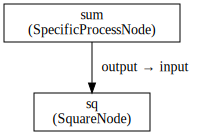

In [11]:
from IPython.display import display

# Deinen Graphen bauen (siehe Demo im Canvas) …
g = ProcessGraph()
g.add_node("sum", SpecificProcessNode())
g.add_node("sq", SquareNode())
g.connect(("sum", "output"), ("sq", "input"))

# Direkt anzeigen (SVG)
display(g.to_graphviz(name="SumSquare", rankdir="TD"))


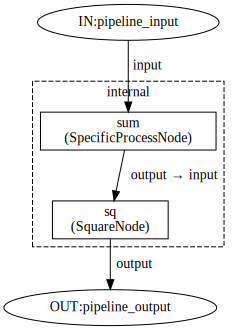

In [12]:
comp = CompositeNode(name="Pipeline")
comp.add("sum", SpecificProcessNode())
comp.add("sq", SquareNode())
comp.connect(("sum", "output"), ("sq", "input"))
comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

display(comp.to_graphviz(name="Pipeline", include_exposed=True, rankdir="TD"))


In [13]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List, Mapping, MutableMapping, Optional, Protocol, Tuple, Type, TypeVar, Generic
from collections import defaultdict, deque
import math

# Optional: Graphviz für Notebook-Visualisierung
try:
    from graphviz import Source  # pip install graphviz  (System: apt/yum install graphviz)
    _HAS_GRAPHVIZ = True
except Exception:
    Source = None  # type: ignore[assignment]
    _HAS_GRAPHVIZ = False


# -------------------------
# Core Data Model
# -------------------------

@dataclass
class Attribute:
    name: str
    dtype: Type = object
    value: Any = None
    unit: str = ""
    description: str = ""
    label: str = ""
    required: bool = False


@dataclass
class ProcessData:
    """Container für Daten + Metadaten.

    - attrs: Map von Attributname -> Attribute
    - Methoden add/get/is_complete
    """
    name: str = "data"
    attrs: Dict[str, Attribute] = field(default_factory=dict)

    def add(self, name: str, value: Any = None, dtype: Type = object, **kw) -> None:
        self.attrs[name] = Attribute(name=name, value=value, dtype=dtype, **kw)

    def get(self, name: str) -> Attribute:
        if name not in self.attrs:
            raise KeyError(f"Attribut '{name}' fehlt in {self.name}.")
        return self.attrs[name]

    def is_complete(self) -> bool:
        for a in self.attrs.values():
            if a.required and a.value is None:
                return False
        return True

    # Convenience: Direktzugriff via .value, .dtype
    @property
    def md(self) -> Mapping[str, Attribute]:
        return self.attrs


# -------------------------
# Ports & Nodes
# -------------------------

@dataclass(frozen=True)
class PortSpec:
    name: str
    dtype: Type[ProcessData] = ProcessData
    optional: bool = False
    many: bool = False  # Mehrfach zulässig (Liste von Verbindungen)


I = TypeVar("I", bound=ProcessData)
O = TypeVar("O", bound=ProcessData)


class Node(Protocol):
    name: str
    input_ports: Mapping[str, PortSpec]
    output_ports: Mapping[str, PortSpec]

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        ...

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        ...


@dataclass
class BaseNode:
    name: str = "Node"
    input_ports: Dict[str, PortSpec] = field(default_factory=dict)
    output_ports: Dict[str, PortSpec] = field(default_factory=dict)

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        # 1) Alle geforderten Ports vorhanden?
        for pname, pspec in self.input_ports.items():
            if not pspec.optional and pname not in inputs:
                raise ValueError(f"[{self.name}] Fehlender Input-Port: {pname}")

        # 2) Typ & Vollständigkeit prüfen
        for pname, pdata in inputs.items():
            if pname not in self.input_ports:
                raise ValueError(f"[{self.name}] Unerwarteter Input-Port: {pname}")
            pspec = self.input_ports[pname]
            if not isinstance(pdata, pspec.dtype):
                raise TypeError(
                    f"[{self.name}] Port '{pname}' erwartet {pspec.dtype.__name__}, bekam {type(pdata).__name__}"
                )
            if not pdata.is_complete():
                raise ValueError(f"[{self.name}] Port '{pname}' ist nicht vollständig.")

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        raise NotImplementedError


# -------------------------
# Beispiel-spezifische Daten & Nodes
# -------------------------

class SpecificInput(ProcessData):
    def __init__(self, name: str = "SpecificInput", **kwargs: Any):
        super().__init__(name=name)
        # Default-Attribute
        self.add("a", None, float, unit="-", description="my a value", label="$a$", required=True)
        self.add("b", None, int, unit="MPa", description="my b value", label="$b$", required=True)
        # Werte aus kwargs setzen (vereinfachte Variante):
        for k, v in kwargs.items():
            if k in self.attrs:
                self.attrs[k].value = v
            else:
                # On-the-fly Zusatzattribut
                self.add(k, v)


class SpecificOutput(ProcessData):
    pass


@dataclass
class SpecificProcessNode(BaseNode):
    """c = a + b"""
    def __init__(self, name: str = "SpecificProcess"):
        super().__init__(
            name=name,
            input_ports={
                "input": PortSpec("input", dtype=SpecificInput)
            },
            output_ports={
                "output": PortSpec("output", dtype=SpecificOutput)
            }
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificInput = inputs["input"]  # type: ignore[assignment]
        a = inp.get("a").value
        b = inp.get("b").value
        out = SpecificOutput(name="out")
        out.add("c", a + b, float, description="a+b")
        return {"output": out}


@dataclass
class SquareNode(BaseNode):
    """d = c**2"""
    def __init__(self, name: str = "Square"):
        super().__init__(
            name=name,
            input_ports={"input": PortSpec("input", dtype=SpecificOutput)},
            output_ports={"output": PortSpec("output", dtype=SpecificOutput)},
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificOutput = inputs["input"]  # type: ignore[assignment]
        c = inp.get("c").value
        out = SpecificOutput(name="out2")
        out.add("d", float(c) ** 2, float, description="(a+b)^2")
        return {"output": out}


# -------------------------
# Prozessgraph (DAG) & Runner
# -------------------------

@dataclass(frozen=True)
class Edge:
    src_node: str
    src_port: str
    dst_node: str
    dst_port: str


@dataclass
class ProcessGraph:
    nodes: Dict[str, BaseNode] = field(default_factory=dict)
    edges: List[Edge] = field(default_factory=list)

    def add_node(self, node_id: str, node: BaseNode) -> None:
        if node_id in self.nodes:
            raise KeyError(f"Node-ID bereits vergeben: {node_id}")
        self.nodes[node_id] = node

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        s_node, s_port = src
        d_node, d_port = dst
        if s_node not in self.nodes or d_node not in self.nodes:
            raise KeyError("Quelle oder Ziel-Node unbekannt")
        self.edges.append(Edge(s_node, s_port, d_node, d_port))

    def _toposort(self, external_inputs: Dict[Tuple[str, str], ProcessData]) -> List[str]:
        # Kantenstruktur: von Node -> Liste Zielknoten
        outgoing: Dict[str, List[str]] = defaultdict(list)
        indeg: Dict[str, int] = {nid: 0 for nid in self.nodes}

        # Indegree zählt nur Kanten, die *Pflicht*-Inputs abdecken; optional ignorieren
        for e in self.edges:
            outgoing[e.src_node].append(e.dst_node)
            dst_node = self.nodes[e.dst_node]
            pspec = dst_node.input_ports.get(e.dst_port)
            if pspec and not pspec.optional:
                indeg[e.dst_node] += 1

        # Externe Inputs reduzieren die Indegree-Anforderungen
        for (nid, port), _ in external_inputs.items():
            node = self.nodes[nid]
            pspec = node.input_ports.get(port)
            if pspec and not pspec.optional:
                # Wenn es keine eingehende Kante für diesen Pflichtport gibt, dann gilt er als gedeckt
                # (praktisch: wir behandeln externen Input wie eine Kante von einer "Quelle").
                # Indegree auf keinen Fall unter 0 bringen.
                indeg[nid] = max(0, indeg[nid] - 1)

        q = deque([nid for nid, d in indeg.items() if d == 0])
        order: List[str] = []
        seen = set()
        while q:
            u = q.popleft()
            if u in seen:
                continue
            seen.add(u)
            order.append(u)
            for v in outgoing[u]:
                # Only decrement if that edge feeds a required port
                pspec = self.nodes[v].input_ports.get(
                    next((e.dst_port for e in self.edges if e.src_node == u and e.dst_node == v), "")
                )
                if pspec and not pspec.optional:
                    indeg[v] -= 1
                    if indeg[v] == 0:
                        q.append(v)
        if len(order) != len(self.nodes):
            raise RuntimeError("Zyklische Abhängigkeiten oder unaufgelöste Pflicht-Inputs im Graphen.")
        return order

    def run(
        self,
        external_inputs: Dict[Tuple[str, str], ProcessData],
        wanted_outputs: Optional[List[Tuple[str, str]]] = None,
    ) -> Dict[Tuple[str, str], ProcessData]:
        """Führt den DAG aus.

        external_inputs: Mapping (node_id, port_name) -> ProcessData
        wanted_outputs: Liste der gewünschten Ergebnis-Ports
        """
        # Eingangs-Puffer je Node/Port
        inbox: Dict[str, Dict[str, ProcessData]] = defaultdict(dict)
        for (nid, port), pdata in external_inputs.items():
            inbox[nid][port] = pdata

        # Kantenindex src -> [(dst, dst_port, src_port)]
        fanout: Dict[str, List[Tuple[str, str, str]]] = defaultdict(list)
        for e in self.edges:
            fanout[e.src_node].append((e.dst_node, e.dst_port, e.src_port))

        order = self._toposort(external_inputs)

        # Ausführen, sobald Inputs eines Nodes valide sind
        produced: Dict[Tuple[str, str], ProcessData] = {}
        for nid in order:
            node = self.nodes[nid]
            # Prüfen, ob für alle Pflicht-Ports Daten da sind
            inputs = inbox.get(nid, {})

            # Falls Ports optional sind, stört das Fehlen nicht; validate_inputs prüft Pflichtports
            node.validate_inputs(inputs)
            outputs = node.run(inputs)

            # Outputs verteilen
            for oport, pdata in outputs.items():
                produced[(nid, oport)] = pdata
                for (dst, dport, sport) in fanout[nid]:
                    if sport == oport:
                        inbox[dst][dport] = pdata

        if wanted_outputs is None:
            # Standard: Alle Leaf-Outputs liefern
            # Leafs = Nodes ohne ausgehende Kanten
            has_out = {e.src_node for e in self.edges}
            leafs = [nid for nid in self.nodes if nid not in has_out]
            wanted_outputs = []
            for nid in leafs:
                for op in self.nodes[nid].output_ports.keys():
                    wanted_outputs.append((nid, op))

        result = {key: produced[key] for key in wanted_outputs if key in produced}
        return result

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box") -> str:
        """Erzeugt einen Graphviz-DOT-String für den aktuellen DAG."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")
        lines.append(f"  node [shape={node_shape}];")

        # Nodes
        for nid, node in self.nodes.items():
            label = f"{nid}\n({node.__class__.__name__})"
            lines.append(f'  "{nid}" [label="{label}"];')

        # Edges mit Port-Labels
        for e in self.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'  "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box", *, format: str = "svg"):
        """Gibt ein `graphviz.Source`-Objekt zurück, ideal für Jupyter-Notebooks.
        Nutzung: `display(g.to_graphviz())`
        """
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir, node_shape=node_shape)
        return Source(dot, format=format)


# -------------------------
# CompositeNode: Bündelt Teilprozesse zu einem Prozess
# -------------------------

@dataclass
class CompositeNode(BaseNode):
    graph: ProcessGraph = field(default_factory=ProcessGraph)
    # Externe Ports des Composite -> interne Node/Port
    in_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)
    out_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)

    def __init__(self, name: str = "Composite"):
        super().__init__(name=name)
        self.graph = ProcessGraph()
        self.in_map = {}
        self.out_map = {}
        self.input_ports = {}
        self.output_ports = {}

    def expose_input(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.in_map[external_name] = (node_id, port)
        self.input_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def expose_output(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.out_map[external_name] = (node_id, port)
        self.output_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def add(self, node_id: str, node: BaseNode) -> None:
        self.graph.add_node(node_id, node)

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        self.graph.connect(src, dst)

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        # 1) Composite-Inputs auf interne Ziele abbilden
        ext_in: Dict[Tuple[str, str], ProcessData] = {}
        for ename, pdata in inputs.items():
            if ename not in self.in_map:
                raise KeyError(f"[{self.name}] Unbekannter Composite-Input: {ename}")
            nid, port = self.in_map[ename]
            ext_in[(nid, port)] = pdata

        # 2) Ausführen
        wanted = [(nid, port) for (oname, (nid, port)) in self.out_map.items()]
        produced = self.graph.run(ext_in, wanted_outputs=wanted)

        # 3) Interne Outputs auf externe Namen mappen
        out: Dict[str, ProcessData] = {}
        for oname, (nid, port) in self.out_map.items():
            val = produced.get((nid, port))
            if val is None:
                raise RuntimeError(f"[{self.name}] Erwarteter Output fehlt: {oname}")
            out[oname] = val
        return out

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True) -> str:
        """DOT-String für den Composite inkl. interner Struktur und optionaler IN/OUT-Knoten."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")

        # interner Graph als Cluster
        lines.append("  subgraph cluster_internal {")
        lines.append("    label=\"internal\";")
        lines.append("    style=dashed;")
        lines.append("    node [shape=box];")

        for nid, node in self.graph.nodes.items():
            label = f"{nid}\n({node.__class__.__name__})"
            lines.append(f'    "{nid}" [label="{label}"];')
        for e in self.graph.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'    "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')
        lines.append("  }")

        if include_exposed:
            # Eingänge (Ellipse) -> interne Ziele
            for ename, (nid, port) in self.in_map.items():
                inn = f"IN::{ename}"
                lines.append(f'  "{inn}" [shape=oval,label="IN:{ename}"];')
                lines.append(f'  "{inn}" -> "{nid}" [label="{port}"];')
            # Ausgänge: intern -> OUT-Knoten (Ellipse)
            for oname, (nid, port) in self.out_map.items():
                outn = f"OUT::{oname}"
                lines.append(f'  "{outn}" [shape=oval,label="OUT:{oname}"];')
                lines.append(f'  "{nid}" -> "{outn}" [label="{port}"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True, *, format: str = "svg"):
        """`graphviz.Source`-Objekt für Jupyter: `display(comp.to_graphviz())`"""
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir, include_exposed=include_exposed)
        return Source(dot, format=format)


# -------------------------
# Demo
# -------------------------
if __name__ == "__main__":
    # Einzelne Nodes
    n1 = SpecificProcessNode()
    n2 = SquareNode()

    # Graph
    g = ProcessGraph()
    g.add_node("sum", n1)
    g.add_node("sq", n2)
    g.connect(("sum", "output"), ("sq", "input"))

    # Composite
    comp = CompositeNode(name="Pipeline")
    comp.add("sum", n1)
    comp.add("sq", n2)
    comp.connect(("sum", "output"), ("sq", "input"))
    comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
    comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

    # Eingaben
    inp = SpecificInput(name="input", a=1.2, b=3)

    # Direkt über Graph
    out_graph = g.run({("sum", "input"): inp})
    print("Graph leaf outputs:")
    for (nid, port), pdata in out_graph.items():
        print(nid, port, {k: v.value for k, v in pdata.md.items()})

    # Über Composite
    out_comp = comp.run({"pipeline_input": inp})
    print("Composite output:")
    for k, pdata in out_comp.items():
        print(k, {k2: v.value for k2, v in pdata.md.items()})

    # --- DOT erzeugen ---
    dot_g = g.to_dot(name="SumSquare", rankdir="LR")
    with open("graph.dot", "w", encoding="utf-8") as f:
        f.write(dot_g)
    print("graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png")

    dot_c = comp.to_dot(name="Pipeline", rankdir="LR", include_exposed=True)
    with open("pipeline.dot", "w", encoding="utf-8") as f:
        f.write(dot_c)
    print("pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg")


SyntaxError: unterminated string literal (detected at line 329) (4098526843.py, line 329)

In [33]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List, Mapping, MutableMapping, Optional, Protocol, Tuple, Type, TypeVar, Generic, Literal
from collections import defaultdict, deque
import math

# Optional: Graphviz für Notebook-Visualisierung
try:
    from graphviz import Source  # pip install graphviz  (System: apt/yum install graphviz)
    _HAS_GRAPHVIZ = True
except Exception:
    Source = None  # type: ignore[assignment]
    _HAS_GRAPHVIZ = False


# -------------------------
# Core Data Model
# -------------------------

@dataclass
class Attribute:
    name: str
    dtype: Type = object
    value: Any = None
    unit: str = ""
    description: str = ""
    label: str = ""
    required: bool = False


@dataclass
class ProcessData:
    """Container für Daten + Metadaten.

    - attrs: Map von Attributname -> Attribute
    - Methoden add/get/is_complete
    """
    name: str = "data"
    attrs: Dict[str, Attribute] = field(default_factory=dict)

    def add(self, name: str, value: Any = None, dtype: Type = object, **kw) -> None:
        self.attrs[name] = Attribute(name=name, value=value, dtype=dtype, **kw)

    def get(self, name: str) -> Attribute:
        if name not in self.attrs:
            raise KeyError(f"Attribut '{name}' fehlt in {self.name}.")
        return self.attrs[name]

    def is_complete(self) -> bool:
        for a in self.attrs.values():
            if a.required and a.value is None:
                return False
        return True

    # Convenience: Direktzugriff via .value, .dtype
    @property
    def md(self) -> Mapping[str, Attribute]:
        return self.attrs


# -------------------------
# Ports & Nodes
# -------------------------

@dataclass(frozen=True)
class PortSpec:
    name: str
    dtype: Type[ProcessData] = ProcessData
    optional: bool = False
    many: bool = False  # Mehrfach zulässig (Liste von Verbindungen)


I = TypeVar("I", bound=ProcessData)
O = TypeVar("O", bound=ProcessData)


class Node(Protocol):
    name: str
    input_ports: Mapping[str, PortSpec]
    output_ports: Mapping[str, PortSpec]

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        ...

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        ...


@dataclass
class BaseNode:
    name: str = "Node"
    input_ports: Dict[str, PortSpec] = field(default_factory=dict)
    output_ports: Dict[str, PortSpec] = field(default_factory=dict)

    def validate_inputs(self, inputs: Mapping[str, ProcessData]) -> None:
        # 1) Alle geforderten Ports vorhanden?
        for pname, pspec in self.input_ports.items():
            if not pspec.optional and pname not in inputs:
                raise ValueError(f"[{self.name}] Fehlender Input-Port: {pname}")

        # 2) Typ & Vollständigkeit prüfen
        for pname, pdata in inputs.items():
            if pname not in self.input_ports:
                raise ValueError(f"[{self.name}] Unerwarteter Input-Port: {pname}")
            pspec = self.input_ports[pname]
            if not isinstance(pdata, pspec.dtype):
                raise TypeError(
                    f"[{self.name}] Port '{pname}' erwartet {pspec.dtype.__name__}, bekam {type(pdata).__name__}"
                )
            if not pdata.is_complete():
                raise ValueError(f"[{self.name}] Port '{pname}' ist nicht vollständig.")

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        raise NotImplementedError


# -------------------------
# Beispiel-spezifische Daten & Nodes
# -------------------------

class SpecificInput(ProcessData):
    def __init__(self, name: str = "SpecificInput", **kwargs: Any):
        super().__init__(name=name)
        # Default-Attribute
        self.add("a", None, float, unit="-", description="my a value", label="$a$", required=True)
        self.add("b", None, int, unit="MPa", description="my b value", label="$b$", required=True)
        # Werte aus kwargs setzen (vereinfachte Variante):
        for k, v in kwargs.items():
            if k in self.attrs:
                self.attrs[k].value = v
            else:
                # On-the-fly Zusatzattribut
                self.add(k, v)


class SpecificOutput(ProcessData):
    pass


@dataclass
class SpecificProcessNode(BaseNode):
    """c = a + b"""
    def __init__(self, name: str = "SpecificProcess"):
        super().__init__(
            name=name,
            input_ports={
                "input": PortSpec("input", dtype=SpecificInput)
            },
            output_ports={
                "output": PortSpec("output", dtype=SpecificOutput)
            }
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificInput = inputs["input"]  # type: ignore[assignment]
        a = inp.get("a").value
        b = inp.get("b").value
        out = SpecificOutput(name="out")
        out.add("c", a + b, float, description="a+b")
        return {"output": out}


@dataclass
class SquareNode(BaseNode):
    """d = c**2"""
    def __init__(self, name: str = "Square"):
        super().__init__(
            name=name,
            input_ports={"input": PortSpec("input", dtype=SpecificOutput)},
            output_ports={"output": PortSpec("output", dtype=SpecificOutput)},
        )

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        self.validate_inputs(inputs)
        inp: SpecificOutput = inputs["input"]  # type: ignore[assignment]
        c = inp.get("c").value
        out = SpecificOutput(name="out2")
        out.add("d", float(c) ** 2, float, description="(a+b)^2")
        return {"output": out}


# -------------------------
# Prozessgraph (DAG) & Runner
# -------------------------

@dataclass(frozen=True)
class Edge:
    src_node: str
    src_port: str
    dst_node: str
    dst_port: str


@dataclass
class ProcessGraph:
    nodes: Dict[str, BaseNode] = field(default_factory=dict)
    edges: List[Edge] = field(default_factory=list)

    def add_node(self, node_id: str, node: BaseNode) -> None:
        if node_id in self.nodes:
            raise KeyError(f"Node-ID bereits vergeben: {node_id}")
        self.nodes[node_id] = node

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        s_node, s_port = src
        d_node, d_port = dst
        if s_node not in self.nodes or d_node not in self.nodes:
            raise KeyError("Quelle oder Ziel-Node unbekannt")
        self.edges.append(Edge(s_node, s_port, d_node, d_port))

    def _toposort(self, external_inputs: Dict[Tuple[str, str], ProcessData]) -> List[str]:
        # Kantenstruktur: von Node -> Liste Zielknoten
        outgoing: Dict[str, List[str]] = defaultdict(list)
        indeg: Dict[str, int] = {nid: 0 for nid in self.nodes}

        # Indegree zählt nur Kanten, die *Pflicht*-Inputs abdecken; optional ignorieren
        for e in self.edges:
            outgoing[e.src_node].append(e.dst_node)
            dst_node = self.nodes[e.dst_node]
            pspec = dst_node.input_ports.get(e.dst_port)
            if pspec and not pspec.optional:
                indeg[e.dst_node] += 1

        # Externe Inputs reduzieren die Indegree-Anforderungen
        for (nid, port), _ in external_inputs.items():
            node = self.nodes[nid]
            pspec = node.input_ports.get(port)
            if pspec and not pspec.optional:
                # Wenn es keine eingehende Kante für diesen Pflichtport gibt, dann gilt er als gedeckt
                # (praktisch: wir behandeln externen Input wie eine Kante von einer "Quelle").
                # Indegree auf keinen Fall unter 0 bringen.
                indeg[nid] = max(0, indeg[nid] - 1)

        q = deque([nid for nid, d in indeg.items() if d == 0])
        order: List[str] = []
        seen = set()
        while q:
            u = q.popleft()
            if u in seen:
                continue
            seen.add(u)
            order.append(u)
            for v in outgoing[u]:
                # Only decrement if that edge feeds a required port
                pspec = self.nodes[v].input_ports.get(
                    next((e.dst_port for e in self.edges if e.src_node == u and e.dst_node == v), "")
                )
                if pspec and not pspec.optional:
                    indeg[v] -= 1
                    if indeg[v] == 0:
                        q.append(v)
        if len(order) != len(self.nodes):
            raise RuntimeError("Zyklische Abhängigkeiten oder unaufgelöste Pflicht-Inputs im Graphen.")
        return order

    def run(
        self,
        external_inputs: Dict[Tuple[str, str], ProcessData],
        wanted_outputs: Optional[List[Tuple[str, str]]] = None,
    ) -> Dict[Tuple[str, str], ProcessData]:
        """Führt den DAG aus.

        external_inputs: Mapping (node_id, port_name) -> ProcessData
        wanted_outputs: Liste der gewünschten Ergebnis-Ports
        """
        # Eingangs-Puffer je Node/Port
        inbox: Dict[str, Dict[str, ProcessData]] = defaultdict(dict)
        for (nid, port), pdata in external_inputs.items():
            inbox[nid][port] = pdata

        # Kantenindex src -> [(dst, dst_port, src_port)]
        fanout: Dict[str, List[Tuple[str, str, str]]] = defaultdict(list)
        for e in self.edges:
            fanout[e.src_node].append((e.dst_node, e.dst_port, e.src_port))

        order = self._toposort(external_inputs)

        # Ausführen, sobald Inputs eines Nodes valide sind
        produced: Dict[Tuple[str, str], ProcessData] = {}
        for nid in order:
            node = self.nodes[nid]
            # Prüfen, ob für alle Pflicht-Ports Daten da sind
            inputs = inbox.get(nid, {})

            # Falls Ports optional sind, stört das Fehlen nicht; validate_inputs prüft Pflichtports
            node.validate_inputs(inputs)
            outputs = node.run(inputs)

            # Outputs verteilen
            for oport, pdata in outputs.items():
                produced[(nid, oport)] = pdata
                for (dst, dport, sport) in fanout[nid]:
                    if sport == oport:
                        inbox[dst][dport] = pdata

        if wanted_outputs is None:
            # Standard: Alle Leaf-Outputs liefern
            # Leafs = Nodes ohne ausgehende Kanten
            has_out = {e.src_node for e in self.edges}
            leafs = [nid for nid in self.nodes if nid not in has_out]
            wanted_outputs = []
            for nid in leafs:
                for op in self.nodes[nid].output_ports.keys():
                    wanted_outputs.append((nid, op))

        result = {key: produced[key] for key in wanted_outputs if key in produced}
        return result

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box") -> str:
        """Erzeugt einen Graphviz-DOT-String für den aktuellen DAG."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")
        lines.append(f"  node [shape={node_shape}];")

        # Nodes
        for nid, node in self.nodes.items():
            label = f"{nid}\\n({node.__class__.__name__})"
            lines.append(f'  "{nid}" [label="{label}"];')

        # Edges mit Port-Labels
        for e in self.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'  "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "ProcessGraph", rankdir: str = "LR", node_shape: str = "box", *, format: str = "svg"):
        """Gibt ein `graphviz.Source`-Objekt zurück, ideal für Jupyter-Notebooks.
        Nutzung: `display(g.to_graphviz())`
        """
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir, node_shape=node_shape)
        return Source(dot, format=format)


# -------------------------
# CompositeNode: Bündelt Teilprozesse zu einem Prozess
# -------------------------

@dataclass
class CompositeNode(BaseNode):
    graph: ProcessGraph = field(default_factory=ProcessGraph)
    # Externe Ports des Composite -> interne Node/Port
    in_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)
    out_map: Dict[str, Tuple[str, str]] = field(default_factory=dict)

    def __init__(self, name: str = "Composite"):
        super().__init__(name=name)
        self.graph = ProcessGraph()
        self.in_map = {}
        self.out_map = {}
        self.input_ports = {}
        self.output_ports = {}

    def expose_input(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.in_map[external_name] = (node_id, port)
        self.input_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def expose_output(self, external_name: str, node_id: str, port: str, dtype: Type[ProcessData]) -> None:
        self.out_map[external_name] = (node_id, port)
        self.output_ports[external_name] = PortSpec(external_name, dtype=dtype)

    def add(self, node_id: str, node: BaseNode) -> None:
        self.graph.add_node(node_id, node)

    def connect(self, src: Tuple[str, str], dst: Tuple[str, str]) -> None:
        self.graph.connect(src, dst)

    def run(self, inputs: Mapping[str, ProcessData]) -> Dict[str, ProcessData]:
        # 1) Composite-Inputs auf interne Ziele abbilden
        ext_in: Dict[Tuple[str, str], ProcessData] = {}
        for ename, pdata in inputs.items():
            if ename not in self.in_map:
                raise KeyError(f"[{self.name}] Unbekannter Composite-Input: {ename}")
            nid, port = self.in_map[ename]
            ext_in[(nid, port)] = pdata

        # 2) Ausführen
        wanted = [(nid, port) for (oname, (nid, port)) in self.out_map.items()]
        produced = self.graph.run(ext_in, wanted_outputs=wanted)

        # 3) Interne Outputs auf externe Namen mappen
        out: Dict[str, ProcessData] = {}
        for oname, (nid, port) in self.out_map.items():
            val = produced.get((nid, port))
            if val is None:
                raise RuntimeError(f"[{self.name}] Erwarteter Output fehlt: {oname}")
            out[oname] = val
        return out

    # --- DOT/Graphviz ---
    def to_dot(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True) -> str:
        """DOT-String für den Composite inkl. interner Struktur und optionaler IN/OUT-Knoten."""
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")

        # interner Graph als Cluster
        lines.append("  subgraph cluster_internal {")
        lines.append("    label=\"internal\";")
        lines.append("    style=dashed;")
        lines.append("    node [shape=box];")

        for nid, node in self.graph.nodes.items():
            label = f"{nid}\\n({node.__class__.__name__})"
            lines.append(f'    "{nid}" [label="{label}"];')
        for e in self.graph.edges:
            elabel = f"{e.src_port} → {e.dst_port}"
            lines.append(f'    "{e.src_node}" -> "{e.dst_node}" [label="{elabel}"];')
        lines.append("  }")

        if include_exposed:
            # Eingänge (Ellipse) -> interne Ziele
            for ename, (nid, port) in self.in_map.items():
                inn = f"IN::{ename}"
                lines.append(f'  "{inn}" [shape=oval,label="IN:{ename}"];')
                lines.append(f'  "{inn}" -> "{nid}" [label="{port}"];')
            # Ausgänge: intern -> OUT-Knoten (Ellipse)
            for oname, (nid, port) in self.out_map.items():
                outn = f"OUT::{oname}"
                lines.append(f'  "{outn}" [shape=oval,label="OUT:{oname}"];')
                lines.append(f'  "{nid}" -> "{outn}" [label="{port}"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "Composite", rankdir: str = "LR", include_exposed: bool = True, *, format: str = "svg"):
        """`graphviz.Source`-Objekt für Jupyter: `display(comp.to_graphviz())`"""
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir, include_exposed=include_exposed)
        return Source(dot, format=format)


# -------------------------
# Bipartiter Daten/Prozess-Graph (DataFlowGraph)
# -------------------------

@dataclass(frozen=True)
class DataVertex:
    id: str
    role: Literal["in", "out", "free"] = "free"  # "in"/"out" sind an Knotenports gebunden
    owner: Optional[str] = None  # zugehöriger Prozessknoten (proc_id)
    port: Optional[str] = None   # Portname am Prozessknoten
    dtype: Type[ProcessData] = ProcessData


@dataclass
class DataFlowGraph:
    """Bipartiter Graph: Datenknoten und Prozessknoten als separate Knoten.

    Kanten:
      - Data → Proc (Verbrauch: befüllt Input-Port)
      - Proc → Data (Produktion: erzeugt Output-Port)
      - Data → Data (Verschaltung zwischen Prozessen: Outputdaten → Inputdaten)
    """
    procs: Dict[str, BaseNode] = field(default_factory=dict)
    data: Dict[str, DataVertex] = field(default_factory=dict)

    # Edges
    consume: List[Tuple[str, str, str]] = field(default_factory=list)   # (data_id, proc_id, in_port)
    produce: List[Tuple[str, str, str]] = field(default_factory=list)   # (proc_id, out_port, data_id)
    dlinks:  List[Tuple[str, str]]     = field(default_factory=list)    # (data_src_id, data_dst_id)

    # ---- Konstruktion
    def add_proc(self, proc_id: str, node: BaseNode) -> None:
        if proc_id in self.procs:
            raise KeyError(f"Prozess-ID bereits vergeben: {proc_id}")
        self.procs[proc_id] = node

    def add_data(self, data_id: str, *, dtype: Type[ProcessData] = ProcessData,
                 role: Literal["in", "out", "free"] = "free",
                 owner: Optional[str] = None, port: Optional[str] = None) -> None:
        if data_id in self.data:
            raise KeyError(f"Datenknoten-ID bereits vergeben: {data_id}")
        self.data[data_id] = DataVertex(id=data_id, role=role, owner=owner, port=port, dtype=dtype)

    def autowire_proc_ports(self, proc_id: str, *, in_prefix: str = "in", out_prefix: str = "out") -> None:
        node = self.procs[proc_id]
        # für jeden Input-Port einen Datenknoten + Kante Data->Proc
        for pname, pspec in node.input_ports.items():
            did = f"{proc_id}.{in_prefix}.{pname}"
            self.add_data(did, dtype=pspec.dtype, role="in", owner=proc_id, port=pname)
            self.consume.append((did, proc_id, pname))
        # für jeden Output-Port einen Datenknoten + Kante Proc->Data
        for pname, pspec in node.output_ports.items():
            did = f"{proc_id}.{out_prefix}.{pname}"
            self.add_data(did, dtype=pspec.dtype, role="out", owner=proc_id, port=pname)
            self.produce.append((proc_id, pname, did))

    def connect_data(self, src_data: str, dst_data: str) -> None:
        if src_data not in self.data or dst_data not in self.data:
            raise KeyError("Unbekannter Datenknoten in connect_data")
        self.dlinks.append((src_data, dst_data))

    # ---- Ausführung
    def run(self, external_data: Dict[str, ProcessData], wanted: Optional[List[str]] = None) -> Dict[str, ProcessData]:
        """Führt den Graph aus.
        - `external_data`: Mapping data_id -> ProcessData (Seed-Werte)
        - `wanted`: Liste gewünschter Datenknoten-IDs (Standard: alle Out-Knoten)
        """
        values: Dict[str, ProcessData] = {}
        values.update(external_data)

        executed: set[str] = set()

        def propagate_once() -> bool:
            progressed = False
            # Data->Data propagieren
            for s, d in self.dlinks:
                if s in values and d not in values:
                    values[d] = values[s]
                    progressed = True
            return progressed

        made_progress = True
        while made_progress:
            made_progress = False

            # 1) Propagation über Data->Data
            if propagate_once():
                made_progress = True

            # 2) Finde lauffähige Prozessoren
            for pid, node in self.procs.items():
                if pid in executed:
                    continue
                # Eingaben für diesen Prozessor einsammeln
                inmap: Dict[str, str] = {p: d for (d, ppid, p) in self.consume if ppid == pid}
                inputs: Dict[str, ProcessData] = {}
                ready = True
                for pname, pspec in node.input_ports.items():
                    if pname in inmap:
                        did = inmap[pname]
                        if did in values:
                            inputs[pname] = values[did]
                        else:
                            ready = False
                            break
                    elif not pspec.optional:
                        ready = False
                        break
                if not ready:
                    continue

                # Ausführen
                node.validate_inputs(inputs)
                outputs = node.run(inputs)

                # Outputs publishen
                outmap: Dict[str, str] = {p: d for (ppid, p, d) in self.produce if ppid == pid}
                for oname, pdata in outputs.items():
                    if oname in outmap:
                        odid = outmap[oname]
                        values[odid] = pdata
                executed.add(pid)
                made_progress = True

            # 3) Nach Publish erneut Data->Data propagieren
            if propagate_once():
                made_progress = True

        # Fertig. Prüfen, ob gewünschte Daten vorhanden.
        if wanted is None:
            wanted = [dv.id for dv in self.data.values() if dv.role == "out"]
        missing = [w for w in wanted if w not in values]
        if missing:
            raise RuntimeError(f"Fehlende Ergebnisse: {missing}")
        return {w: values[w] for w in wanted}

    # ---- DOT/Graphviz
    def to_dot(self, name: str = "DataFlow", rankdir: str = "LR") -> str:
        lines: List[str] = []
        lines.append(f'digraph "{name}" {{')
        lines.append(f"  rankdir={rankdir};")

        # Teilgraphen pro Prozess
        for pid, node in self.procs.items():
            lines.append(f"  subgraph cluster_{pid} {{")
            lines.append(f"    label=\"{pid}\\n({node.__class__.__name__})\";")
            lines.append("    style=rounded;")
            lines.append("    node [shape=box];")
            lines.append(f'    "{pid}" [label="{pid}"];')
            # Datenknoten des Prozesses
            for dv in self.data.values():
                if dv.owner == pid:
                    shape = "oval"
                    lines.append(f'    "{dv.id}" [shape={shape},label="{dv.id.split(".")[-1]}"];')
            # interne Kanten
            for (did, ppid, port) in self.consume:
                if ppid == pid:
                    lines.append(f'    "{did}" -> "{pid}" [label="{port}"];')
            for (ppid, port, did) in self.produce:
                if ppid == pid:
                    lines.append(f'    "{pid}" -> "{did}" [label="{port}"];')
            lines.append("  }")

        # Kanten zwischen Datenknoten (prozessübergreifend)
        for (s, d) in self.dlinks:
            # nur zeichnen, wenn Quelle/Ziel existieren
            if s in self.data and d in self.data:
                lines.append(f'  "{s}" -> "{d}" [style=dashed,label="data"];')

        lines.append("}")
        return "\n".join(lines)

    def to_graphviz(self, name: str = "DataFlow", rankdir: str = "LR", *, format: str = "svg"):
        if not _HAS_GRAPHVIZ:
            raise RuntimeError("Python-Paket 'graphviz' nicht installiert. `pip install graphviz` und Systempaket 'graphviz' bereitstellen.")
        dot = self.to_dot(name=name, rankdir=rankdir)
        return Source(dot, format=format)


# -------------------------
# Demo (inkl. kleiner Tests)
# -------------------------
if __name__ == "__main__":
    # Einzelne Nodes
    n1 = SpecificProcessNode()
    n2 = SquareNode()

    # Graph (Node-zu-Node-Ports)
    g = ProcessGraph()
    g.add_node("sum", n1)
    g.add_node("sq", n2)
    g.connect(("sum", "output"), ("sq", "input"))

    # Composite
    comp = CompositeNode(name="Pipeline")
    comp.add("sum", SpecificProcessNode())
    comp.add("sq", SquareNode())
    comp.connect(("sum", "output"), ("sq", "input"))
    comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
    comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

    # Eingaben
    inp = SpecificInput(name="input", a=1.2, b=3)

    # Direkt über Graph
    out_graph = g.run({("sum", "input"): inp})
    print("Graph leaf outputs:")
    for (nid, port), pdata in out_graph.items():
        print(nid, port, {k: v.value for k, v in pdata.md.items()})

    # Test 1: Ergebnis aus ProcessGraph (Leaf = sq)
    sq_out = out_graph[("sq", "output")]
    assert abs(sq_out.md["d"].value - 17.64) < 1e-9, "ProcessGraph: d sollte (1.2+3)^2 = 17.64 sein"

    # Über Composite
    out_comp = comp.run({"pipeline_input": inp})
    print("Composite output:")
    for k, pdata in out_comp.items():
        print(k, {k2: v.value for k2, v in pdata.md.items()})

    # Test 2: Ergebnis aus Composite
    comp_out = out_comp["pipeline_output"]
    assert abs(comp_out.md["d"].value - 17.64) < 1e-9, "Composite: d sollte 17.64 sein"

    # --- DOT erzeugen (klassisch) ---
    dot_g = g.to_dot(name="SumSquare", rankdir="LR")
    with open("graph.dot", "w", encoding="utf-8") as f:
        f.write(dot_g)
    print("graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png")

    dot_c = comp.to_dot(name="Pipeline", rankdir="LR", include_exposed=True)
    with open("pipeline.dot", "w", encoding="utf-8") as f:
        f.write(dot_c)
    print("pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg")

    # Mini-Checks für DOT-Inhalt
    assert "rankdir=LR" in dot_g and "SumSquare" in dot_g, "DOT: ProcessGraph Grundstruktur fehlt"
    assert "subgraph cluster_internal" in dot_c and "IN::pipeline_input" in dot_c, "DOT: Composite-Cluster/IN fehlt"

    # --- Bipartiter Graph (DataFlowGraph) ---
    dfg = DataFlowGraph()
    dfg.add_proc("sum", SpecificProcessNode())
    dfg.add_proc("sq", SquareNode())

    # Automatisch Ports → Datenknoten erzeugen
    dfg.autowire_proc_ports("sum")
    dfg.autowire_proc_ports("sq")

    # Gesamtprozess: Outputdaten von sum → Inputdaten von sq
    dfg.connect_data("sum.out.output", "sq.in.input")

    # Externe Eingangsdaten: befülle sum.in.input
    seed = {"sum.in.input": SpecificInput(a=1.2, b=3)}

    # Ausführen – alle Out-Knoten einsammeln
    res = dfg.run(seed)
    print("DataFlowGraph results:")
    for k, v in res.items():
        print(k, {ak: av.value for ak, av in v.md.items()})

    # Tests 3/4: DataFlowGraph Ergebnisse prüfen
    assert "sum.out.output" in res and "c" in res["sum.out.output"].md, "DFG: sum.out.output/c fehlt"
    assert abs(res["sum.out.output"].md["c"].value - 4.2) < 1e-9, "DFG: c sollte 4.2 sein"
    assert "sq.out.output" in res and "d" in res["sq.out.output"].md, "DFG: sq.out.output/d fehlt"
    assert abs(res["sq.out.output"].md["d"].value - 17.64) < 1e-9, "DFG: d sollte 17.64 sein"

    # DOT für den bipartiten Graphen
    with open("dataflow.dot", "w", encoding="utf-8") as f:
        f.write(dfg.to_dot(name="DataFlow", rankdir="LR"))
    print("dataflow.dot geschrieben. → dot -Tsvg dataflow.dot -o dataflow.svg")

    # Optional: Notebook-Render prüfen (nur wenn graphviz installiert)
    if _HAS_GRAPHVIZ:
        assert isinstance(g.to_graphviz(), Source), "to_graphviz(ProcessGraph) sollte Source liefern"
        assert isinstance(comp.to_graphviz(), Source), "to_graphviz(Composite) sollte Source liefern"
        assert isinstance(dfg.to_graphviz(), Source), "to_graphviz(DataFlowGraph) sollte Source liefern"

    print("Alle Tests OK.")

Graph leaf outputs:
sq output {'d': 17.64}
Composite output:
pipeline_output {'d': 17.64}
graph.dot geschrieben. → Rendern z.B.: dot -Tpng graph.dot -o graph.png
pipeline.dot geschrieben. → Rendern z.B.: dot -Tsvg pipeline.dot -o pipeline.svg
DataFlowGraph results:
sum.out.output {'c': 4.2}
sq.out.output {'d': 17.64}
dataflow.dot geschrieben. → dot -Tsvg dataflow.dot -o dataflow.svg
Alle Tests OK.


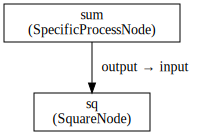

In [34]:
from IPython.display import display

# 1) Knoten + einfacher DAG
g = ProcessGraph()
g.add_node("sum", SpecificProcessNode())
g.add_node("sq",  SquareNode())
g.connect(("sum", "output"), ("sq", "input"))

display(g.to_graphviz(name="SumSquare", rankdir="TD"))

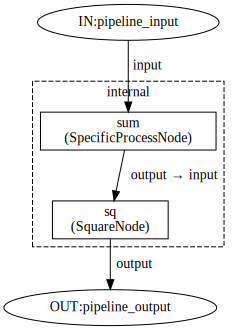

In [35]:
# 2) Composite
comp = CompositeNode(name="Pipeline")
comp.add("sum", SpecificProcessNode())
comp.add("sq",  SquareNode())
comp.connect(("sum", "output"), ("sq", "input"))
comp.expose_input("pipeline_input", "sum", "input", dtype=SpecificInput)
comp.expose_output("pipeline_output", "sq", "output", dtype=SpecificOutput)

display(comp.to_graphviz(name="Pipeline", include_exposed=True, rankdir="TD"))

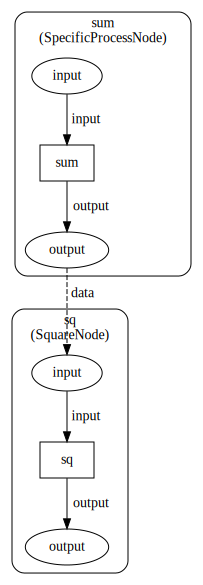

In [36]:
# 3) Bipartiter Daten/Prozess-Graph
dfg = DataFlowGraph()
dfg.add_proc("sum", SpecificProcessNode())
dfg.add_proc("sq",  SquareNode())
dfg.autowire_proc_ports("sum")
dfg.autowire_proc_ports("sq")
dfg.connect_data("sum.out.output", "sq.in.input")

display(dfg.to_graphviz(name="DataFlow", rankdir="TD"))